# Tutorial 8: Classification Analysis II

__Step 1: Generate Dataset:Use the same dataset in Tutorial 4 on Model Overfitting by generating class 0 and 1__

**<font color="red">Code:</font>**

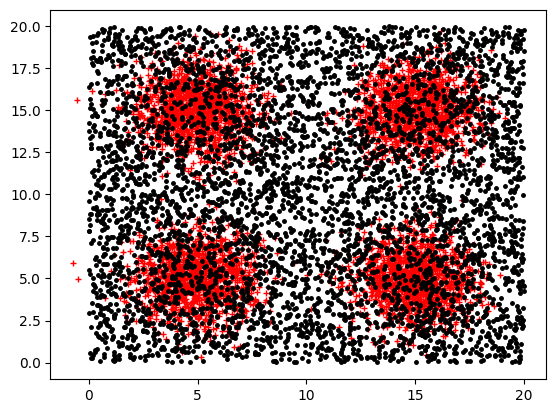

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from numpy.random import random

N = 10000               # number of data instances

mean1 = [5, 15]
mean2 = [15, 15]
mean3 = [15, 5]
mean4 = [5, 5]

cov = [[2, 0], [0, 2]]  # diagonal covariance

np.random.seed(500)
X = np.random.multivariate_normal(mean1, cov, int(N/8))                       # 1250 rows
X = np.concatenate((X, np.random.multivariate_normal(mean2, cov, int(N/8))))  # 1250 rows
X = np.concatenate((X, np.random.multivariate_normal(mean3, cov, int(N/8))))  # 1250 rows
X = np.concatenate((X, np.random.multivariate_normal(mean4, cov, int(N/8))))  # 1250 rows
X = np.concatenate((X, 20*np.random.rand(int(N/2),2)))                        # 5000 rows
Y = np.concatenate((np.ones(int(N/2)),np.zeros(int(N/2))))                    # 10000 class labels (1, 0)
plt.plot(X[:int(N/2),0],X[:int(N/2),1],'r+',X[int(N/2):,0],X[int(N/2):,1],'k.',ms=5)

__Step 2: Split into training and Test set in ratio of 70:30__
        
1)X_train: 70% of Original Data X
    
2)X_test : 30% of Original Data X
    
3)Y_train: 70% of Original Class Label Data Y 
    
4)Y_test : 30% of Original Class Label Data Y

**<font color="red">Code:</font>**

In [2]:
###########################################################
# Create the Training and Test set with split 70:30 
##########################################################

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=12)
from sklearn import tree
from sklearn.metrics import accuracy_score

## Question 1:  Linear Prediction using Linear Support Vector Machine

Linear classifiers such as support vector machine (SVM) constructs a linear separating 
hyperplane to distinguish instances from different classes. 

For support vector machine, the model parameters $(w^*,b^*)$ are estimated by solving the following constrained optimization problem:
\begin{eqnarray*}
&&\min_{w^*,b^*,\{\xi_i\}} \frac{\|w\|^2}{2} + \frac{1}{C} \sum_i \xi_i \\
\textrm{s.t.} && \forall i: y_i\bigg[w^T \phi(x_i) + b\bigg] \ge 1 - \xi_i, \ \ \xi_i \ge 0  
\end{eqnarray*}

__Step:__

1)Import SVC from sklearn.svm

2)Set C range from 0.01,0.1,0.2,0.5,0.8,1,5,10,20,50

3)Repeat the same process of fitting with X_train and Y_train and predicting with X_train adn X_test

4)Calculate the accuracy score for testing and training prediction and plot verus various C

**<font color="red">Code:</font>**

Text(0, 0.5, 'Accuracy')

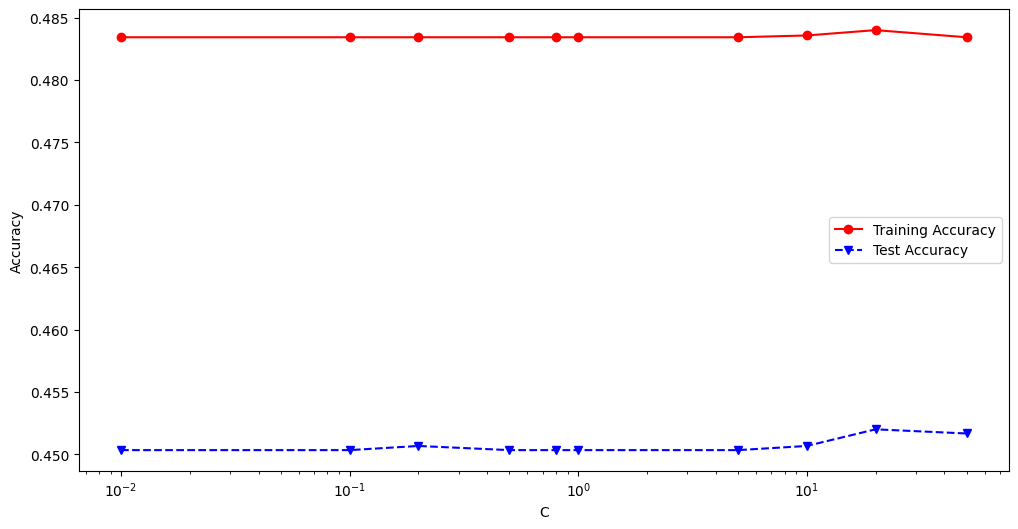

In [3]:
from sklearn.svm import SVC

C = [0.01, 0.1, 0.2, 0.5, 0.8, 1, 5, 10, 20, 50]

SVMtrainAcc = []
SVMtestAcc = []

for param in C:
    clf4 = SVC(C=param,kernel='linear')
    clf4.fit(X_train, Y_train)
    Y_predTrain = clf4.predict(X_train)
    Y_predTest = clf4.predict(X_test)
    SVMtrainAcc.append(accuracy_score(Y_train, Y_predTrain))
    SVMtestAcc.append(accuracy_score(Y_test, Y_predTest))

fig, (ax1) = plt.subplots(1, 1, figsize=(12,6))

ax1.plot(C, SVMtrainAcc, 'ro-', C, SVMtestAcc,'bv--')
ax1.legend(['Training Accuracy','Test Accuracy'])
ax1.set_xlabel('C')
ax1.set_xscale('log')
ax1.set_ylabel('Accuracy')

Observation:Note that linear classifiers perform poorly on the data since the true decision boundaries between 
classes are nonlinear for the given 2-dimensional dataset. Can you visualize?

## Question 2:  Non Linear Support Vector Machine(SVM)

Let try nonlinear support vector machine with a Gaussian radial basis function kernel to fit the 2-dimensional 
dataset.

__Step:__Repeat the whole process of fitting, prediction and accuracy evaluation by setting SVC kernel to rbf and 
gamma=auto

**<font color="red">Code:</font>**

Text(0, 0.5, 'Accuracy')

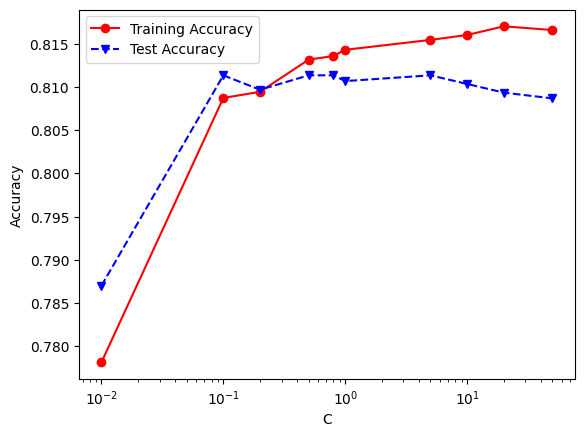

In [4]:
from sklearn.svm import SVC

C = [0.01, 0.1, 0.2, 0.5, 0.8, 1, 5, 10, 20, 50]
SVMtrainAcc = []
SVMtestAcc = []

for param in C:
    clf5 = SVC(C=param,kernel='rbf',gamma='auto')
    clf5.fit(X_train, Y_train)
    Y_predTrain = clf5.predict(X_train)
    Y_predTest = clf5.predict(X_test)
    SVMtrainAcc.append(accuracy_score(Y_train, Y_predTrain))
    SVMtestAcc.append(accuracy_score(Y_test, Y_predTest))

plt.plot(C, SVMtrainAcc, 'ro-', C, SVMtestAcc,'bv--')
plt.legend(['Training Accuracy','Test Accuracy'])
plt.xlabel('C')
plt.xscale('log')
plt.ylabel('Accuracy')

Observation: By using non linear SVM, the accuarcy has improved gradually with higher C(less stringent on regularization)

## Question 3: Neural Network

Text(0, 0.5, 'Accuracy')

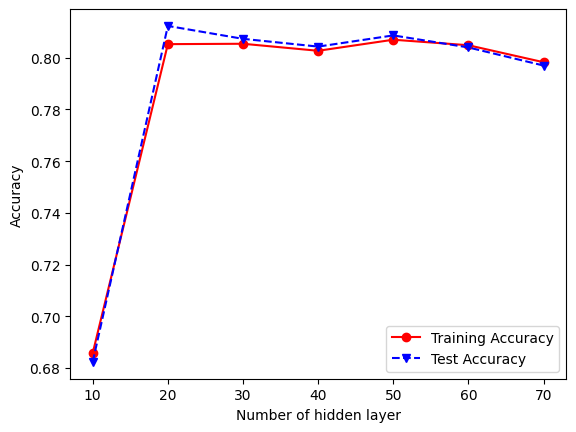

In [5]:
from sklearn.neural_network import MLPClassifier

hidden_layer_sizes = [(10,10,10), (20,20,20), (30,30,30), (40,40,40), (50,50,50), (60,60,60), (70,70,70)]
trainAcc = []
testAcc = []

for k in hidden_layer_sizes:
    clf6 = MLPClassifier(solver='adam',hidden_layer_sizes=k, learning_rate='adaptive',random_state=1,max_iter=1000)
    clf6.fit(X_train, Y_train)
    Y_predTrain = clf6.predict(X_train)
    Y_predTest = clf6.predict(X_test)
    trainAcc.append(accuracy_score(Y_train, Y_predTrain))
    testAcc.append(accuracy_score(Y_test, Y_predTest))
hidden_layer_size=[x[0] for x in hidden_layer_sizes]
plt.plot(hidden_layer_size, trainAcc, 'ro-', hidden_layer_size, testAcc,'bv--')
plt.legend(['Training Accuracy','Test Accuracy'])
plt.xlabel('Number of hidden layer')
plt.ylabel('Accuracy')


## Question 4: Visuilization of Decision Boundary on various classifiers 

Visualization of decision boundary on the following classifier

1)KNN(K=30)

2)Navie Bayes

3)Logistic Regression (C=50)

4)Linear SVM(C=50)

5)Non Linear SVM (RBF)

6)Multi Layer Perceptron (MLP)-Neural Network(3 hiiden layer with 70 Neurons each)

7)Decision Tree (Depth =10)

**<font color="red">Code:using contourf function to plot the decision boundary</font>**

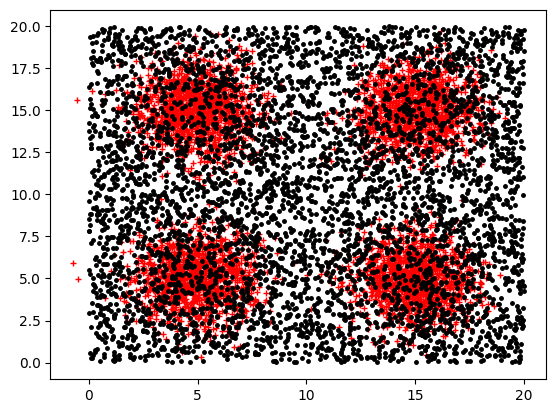

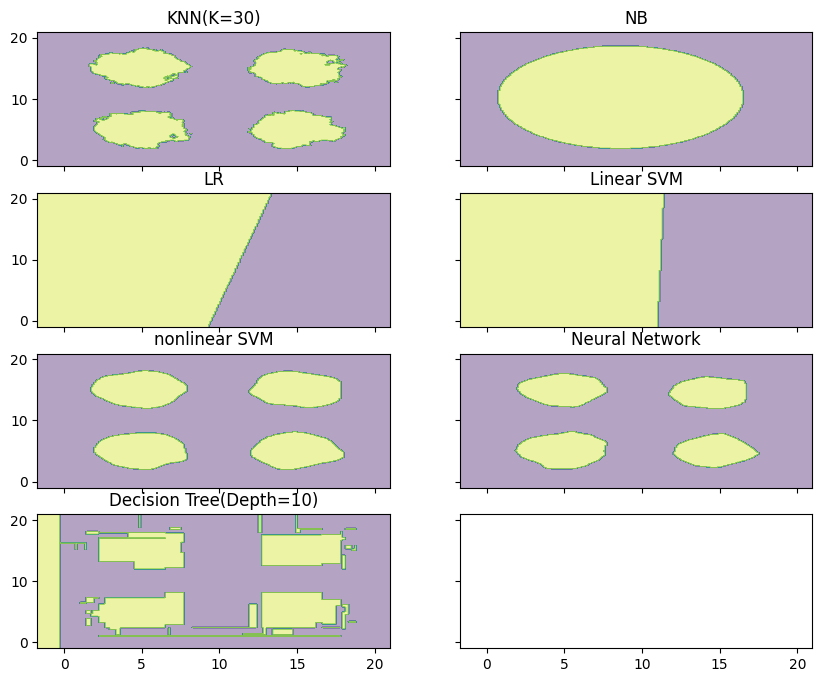

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import linear_model
from sklearn.tree import DecisionTreeClassifier


clf1=KNeighborsClassifier(n_neighbors=30, metric='minkowski', p=2)
clf1.fit(X_train, Y_train)
clf2=GaussianNB()
clf2.fit(X_train, Y_train)
clf3=linear_model.LogisticRegression(C=50)
clf3.fit(X_train, Y_train)
clf4 = SVC(C=50,kernel='linear')
clf4.fit(X_train, Y_train)
clf5 = SVC(C=0.5,kernel='rbf',gamma='auto')
clf5.fit(X_train, Y_train)
clf6 = MLPClassifier(solver='adam',hidden_layer_sizes=(70,70,70), learning_rate='adaptive',random_state=1,max_iter=1000)
clf6.fit(X_train, Y_train)
clf7=DecisionTreeClassifier(max_depth=10)
clf7.fit(X_train, Y_train)

x_min, x_max = X_test[:, 0].min() - 1, X_test[:, 0].max() + 1
y_min, y_max = X_test[:, 1].min() - 1, X_test[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),np.arange(y_min, y_max, 0.1))

plt.plot(X[:int(N/2),0],X[:int(N/2),1],'r+',X[int(N/2):,0],X[int(N/2):,1],'k.',ms=5)

f, axarr = plt.subplots(4, 2, sharex='col', sharey='row', figsize=(10, 8))

for idx, clf, tt in zip([[0, 0],[0,1],[1,0],[1,1],[2,0],[2,1],[3,0]], [clf1,clf2,clf3,clf4,clf5,clf6,clf7],['KNN(K=30)','NB', 'LR','Linear SVM','nonlinear SVM','Neural Network','Decision Tree(Depth=10)']):

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    axarr[idx[0], idx[1]].contourf(xx, yy, Z,alpha=0.4)
    axarr[idx[0], idx[1]].set_title(tt)
plt.show()


Observation: As shown, KNN, Non linear SVM, Neural Network and Decision Tree can follow the contour of class and separate out the 
two binary class well
In terms of accuracy scote obtained earlier on

1)KNN=0.82

2)NB=0.58

3)LR=0.4825

4)Linear SVM=0.4825

5)Non linear SVM=0.8125

6)Neural Network=0.8

7)Decison Tree=0.8